##**🏥 Obesity Level Prediction Classification**



**Identity**

- Hellen Eleora Chika Calysta
- 103132400042
-

#**1. Business Understanding**

**Background**

Obesity is one of the most common health problems worldwide. It can increase the risk of several chronic diseases such as diabetes, hypertension, and heart disease. Lifestyle factors such as eating habits, physical activity, water consumption, and family history play an important role in determining obesity levels.

Machine Learning can be utilized to classify obesity levels based on personal and lifestyle characteristics.

**Problem Statement**

How can machine learning models accurately classify obesity levels based on physical condition and eating habits?

**Objectives**


*   Analyze factors related to obesity.
*   Build machine learning classification models.
*   Compare model performance.
*   Determine the best model for obesity prediction.









#**2. Dataset**

**Dataset Source**

Dataset used in this project:

**Obesity Levels based on Eating Habits and Physical Condition Dataset**

Source:
[UCI Obesity Dataset](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition?utm_source=chatgpt.com)

**Dataset Description**

The dataset contains information about eating habits, physical condition, and lifestyle factors that influence obesity levels.

**Number of Records**
* 2,111 observations

**Number of Features**
* 16 input features
* 1 target variable

**Features Description**

| Feature                        | Description                               |
| ------------------------------ | ----------------------------------------- |
| Gender                         | Gender                                    |
| Age                            | Age                                       |
| Height                         | Height                                    |
| Weight                         | Weight                                    |
| family_history_with_overweight | Family history of overweight              |
| FAVC                           | Frequent consumption of high-calorie food |
| FCVC                           | Frequency of vegetable consumption        |
| NCP                            | Number of main meals                      |
| CAEC                           | Consumption between meals                 |
| SMOKE                          | Smoking habit                             |
| CH2O                           | Daily water consumption                   |
| SCC                            | Calorie consumption monitoring            |
| FAF                            | Physical activity frequency               |
| TUE                            | Time spent using technology devices       |
| CALC                           | Alcohol consumption                       |
| MTRANS                         | Transportation used                       |
| NObeyesdad                     | Obesity level (Target)                    |

**Target Classes**

- Insufficient_Weight
- Normal_Weight
- Overweight_Level_I
- Overweight_Level_II
- Obesity_Type_I
- Obesity_Type_II
- Obesity_Type_III



#**3. Import Libraries**

In [92]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

#**4. Load Dataset**

In [93]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

print(df.head())
print(df.info())

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

#**5. Data Understanding**

**Dataset Shape**

In [94]:
df.shape

(2111, 17)

**Dataset Information**

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

**Statistical Summary**

In [96]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


**Check Missing Values**

In [97]:
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


**Check Duplicate Values**

In [98]:
df.duplicated().sum()

np.int64(24)

**6. Data Cleaning**

**Remove Duplicate Data**

In [99]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (2111, 17)
After: (2087, 17)


**Verify Missing Values**

In [100]:
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


#**7. Exploratory Data Analysis (EDA)**

**Distribution of Obesity Levels**

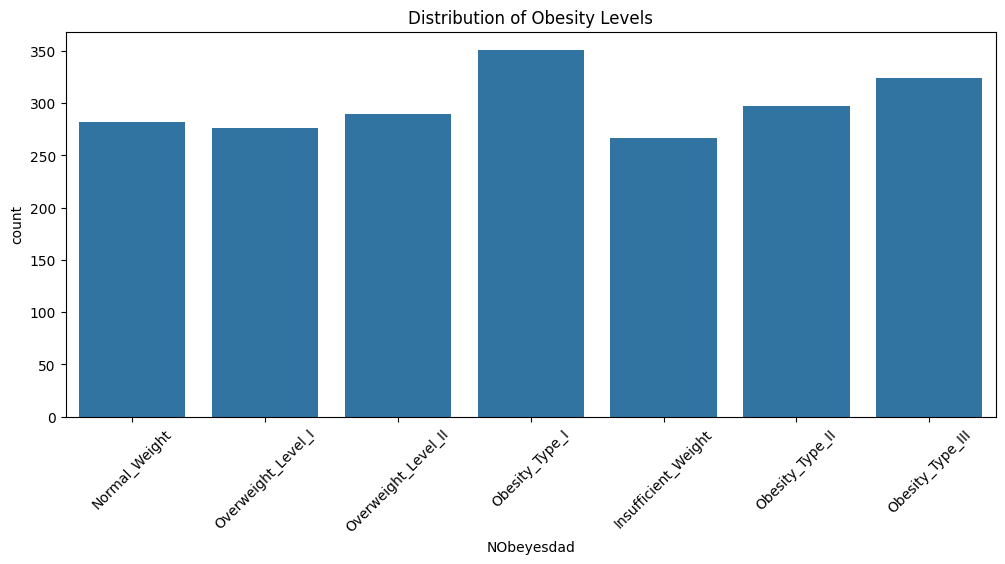

In [101]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='NObeyesdad'
)

plt.xticks(rotation=45)
plt.title("Distribution of Obesity Levels")
plt.show()

**Insight**

- Dataset cukup seimbang.
- Terdapat 7 kategori obesitas.

**Gender Distribution**

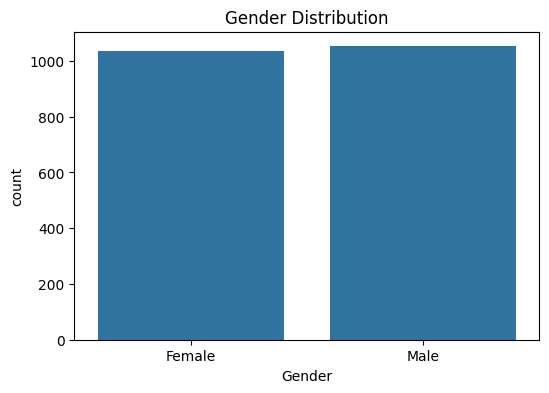

In [102]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Gender'
)

plt.title("Gender Distribution")
plt.show()

**Age Distribution**

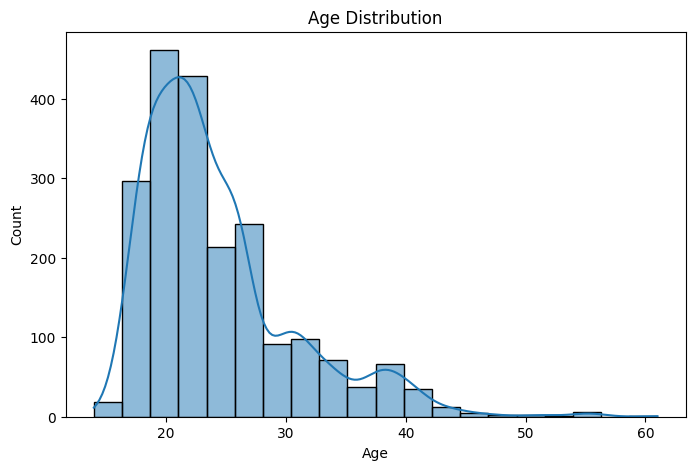

In [103]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.show()

**Weight Distribution**

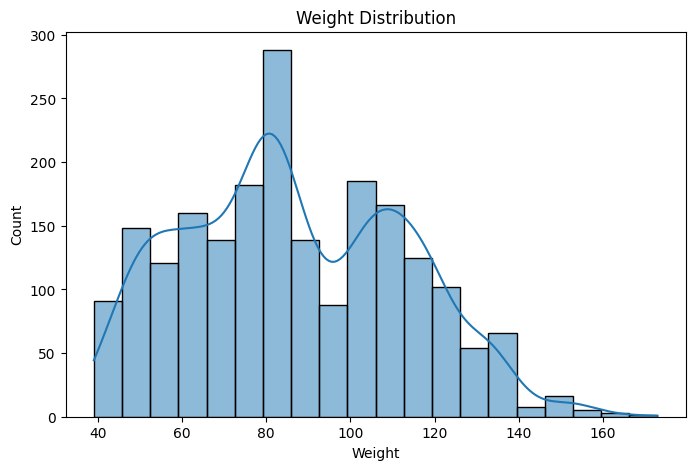

In [104]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Weight'],
    bins=20,
    kde=True
)

plt.title("Weight Distribution")
plt.show()

**Height Distribution**

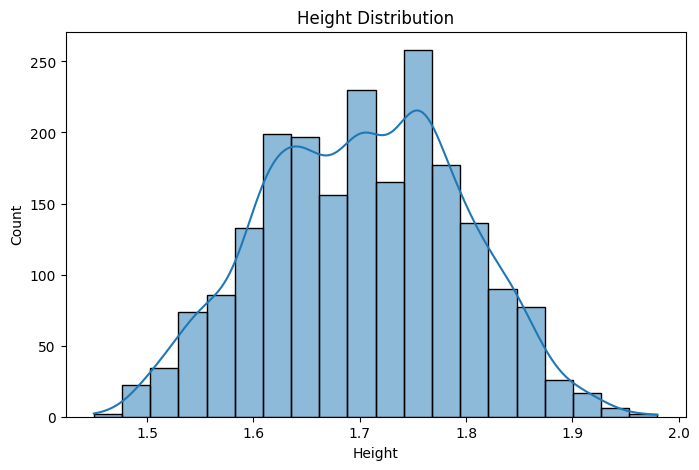

In [105]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Height'],
    bins=20,
    kde=True
)

plt.title("Height Distribution")
plt.show()

**Physical Activity vs Obesity**

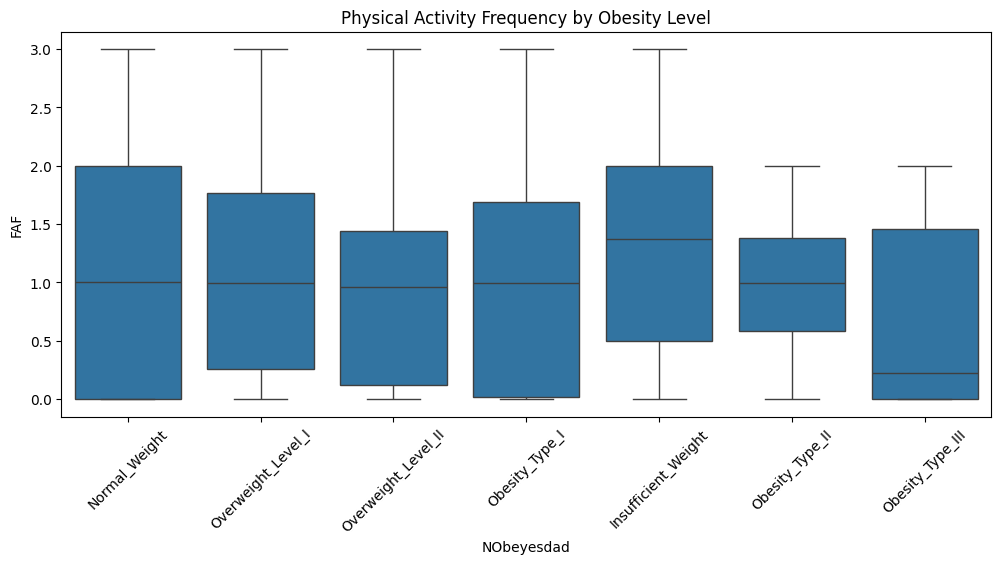

In [106]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x='NObeyesdad',
    y='FAF'
)

plt.xticks(rotation=45)

plt.title("Physical Activity Frequency by Obesity Level")
plt.show()

**Insight**

- Semakin rendah aktivitas fisik, kecenderungan obesitas meningkat.

**Water Consumption vs Obesity**

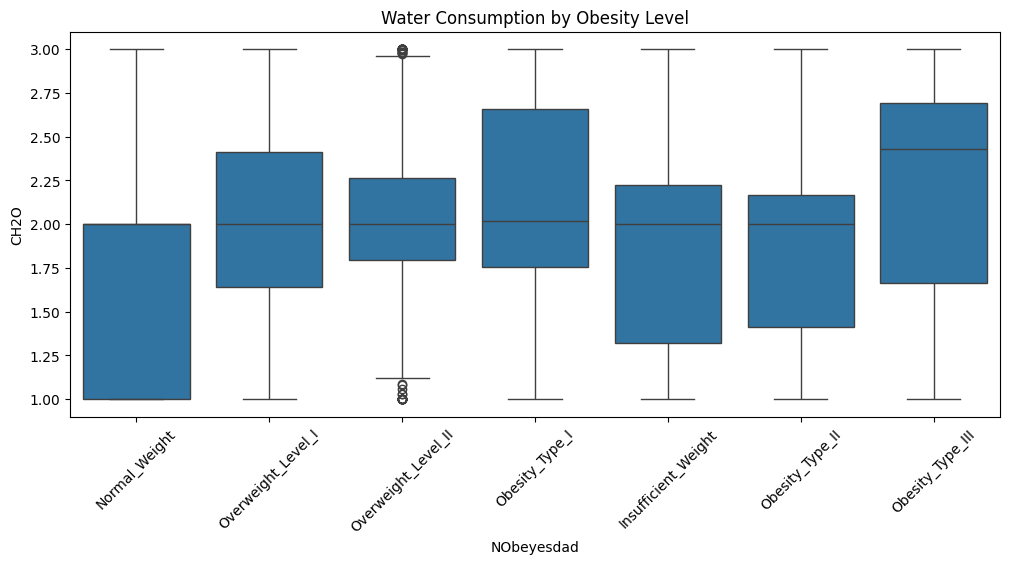

In [107]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x='NObeyesdad',
    y='CH2O'
)

plt.xticks(rotation=45)

plt.title("Water Consumption by Obesity Level")
plt.show()

#**8. Data Preprocessing**

**Encoding Categorical Features**

In [108]:
label_encoder = LabelEncoder()

for column in df.columns:

    if df[column].dtype == 'object':

        df[column] = label_encoder.fit_transform(df[column])

**Correlation Heatmap**

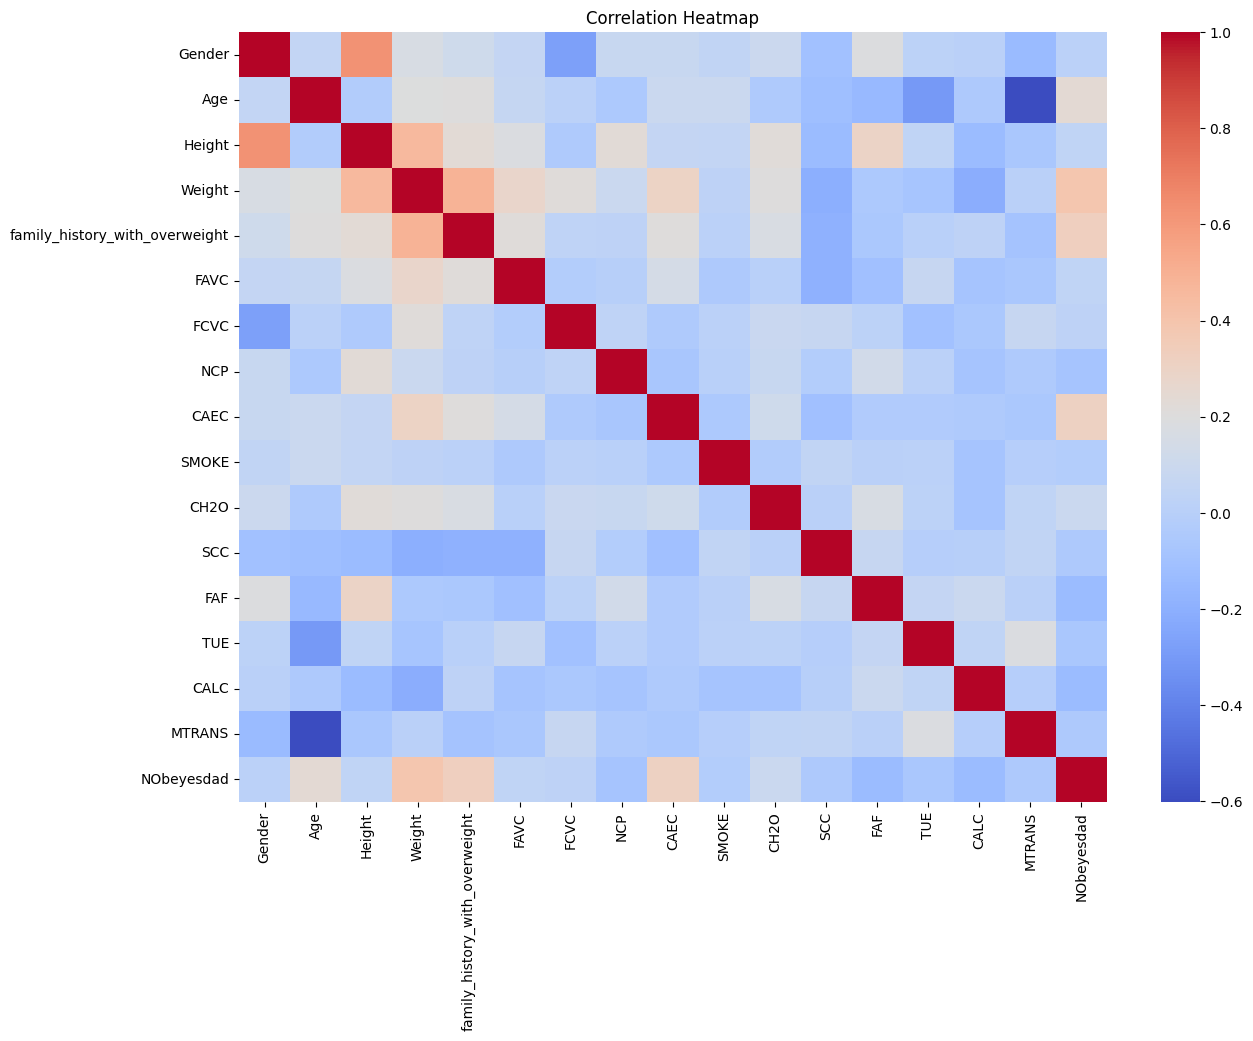

In [109]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

**Feature Selection**

In [110]:
X = df.drop(
    'NObeyesdad',
    axis=1
)

y = df['NObeyesdad']

**Feature Scalling**

In [111]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

**Train Test Split**

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (1669, 16)
Testing Set  : (418, 16)


#**9. Modeling**

**Decision Tree Classifier**

In [113]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_pred = dt_model.predict(
    X_test
)

**Random Forest Classifier**

In [114]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

**XGBoost Classifier**

In [115]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

#**10. Model Evaluation**

**Accuracy Score**

In [116]:
dt_acc = accuracy_score(
    y_test,
    dt_pred
)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

accuracy_table = pd.DataFrame({
    'Model':[
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy':[
        dt_acc,
        rf_acc,
        xgb_acc
    ]
})

accuracy_table.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
2,XGBoost,0.968900
1,Random Forest,0.954545
0,Decision Tree,0.925837


**Classification Report**

In [117]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        53
           1       0.84      0.95      0.89        57
           2       1.00      0.97      0.99        70
           3       0.98      1.00      0.99        60
           4       1.00      0.98      0.99        65
           5       0.89      0.91      0.90        55
           6       0.96      0.91      0.94        58

    accuracy                           0.95       418
   macro avg       0.95      0.95      0.95       418
weighted avg       0.96      0.95      0.96       418



**Confusion Matrix**

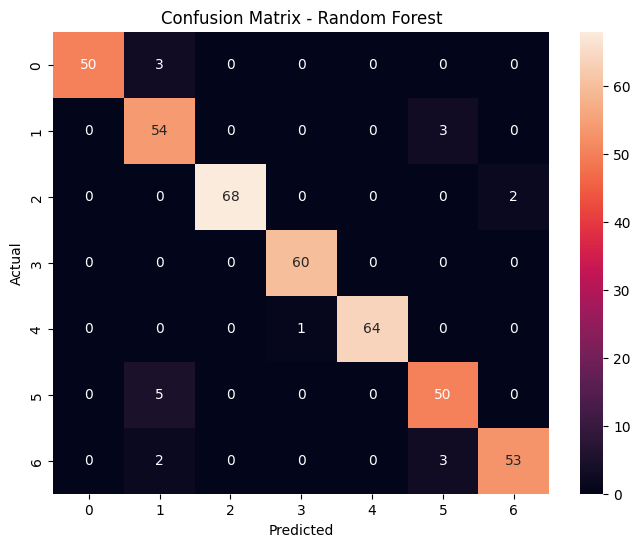

In [118]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Confusion Matrix - Random Forest"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Feature Importance**

In [119]:
importance = pd.DataFrame({
    'Feature':
    df.drop(
        'NObeyesdad',
        axis=1
    ).columns,

    'Importance':
    rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
3,Weight,0.348154
2,Height,0.099472
1,Age,0.095735
6,FCVC,0.091018
0,Gender,0.054236
7,NCP,0.049767
13,TUE,0.044973
12,FAF,0.042886
10,CH2O,0.038234
4,family_history_with_overweight,0.031452


**Feature Importance Visualization**

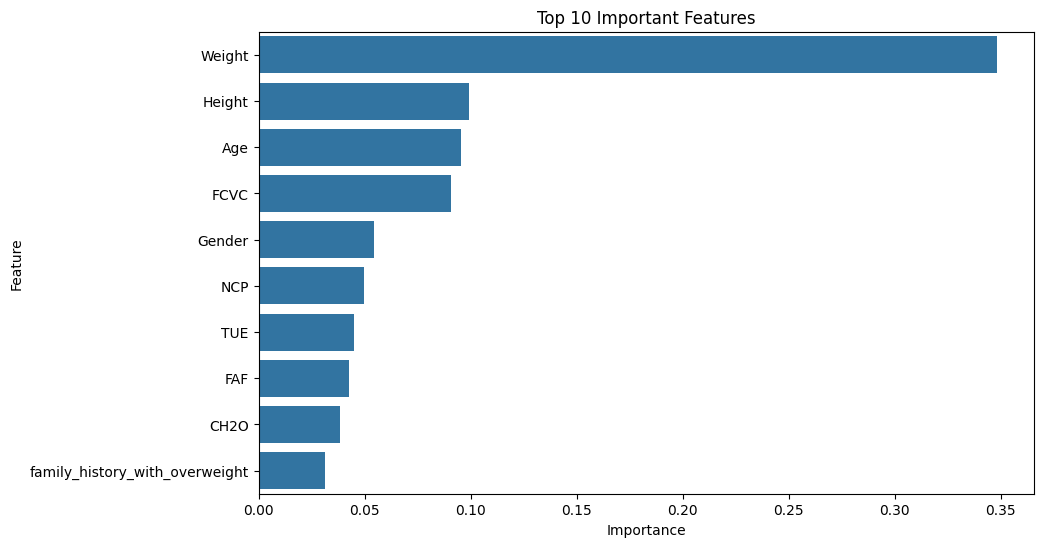

In [120]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

## **11. Conclusion**

Based on the experimental results:

- Random Forest achieved the highest accuracy among all models.
- Weight, Height, Age, and Physical Activity Frequency were the most influential factors.
- Machine Learning can effectively classify obesity levels using lifestyle and physical condition data.
- Random Forest is recommended as the final model for obesity prediction.

#**12. Save Best Model**

In [121]:
import joblib

joblib.dump(
    rf_model,
    "random_forest_obesity_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!
